In [12]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 47.9 MB/s eta 0:00:0000:0100:01


In [1]:
# 일단 홈 디렉토리로 나갑니다 (에러 해결 핵심)
%cd ~

# 다시 폴더를 만듭니다
!mkdir -p ~/work/mpii

# 이제 새로 만든 폴더로 들어갑니다
%cd ~/work/mpii

/home/jovyan
/home/jovyan/work/mpii


In [2]:
!ls -F /data/

ls: cannot access '/data/': No such file or directory


In [3]:
# 1. 홈 디렉토리 안의 data 폴더 확인
!ls -F ~/data/

# 2. 만약 위에서 안 나온다면, 프로젝트용 공용 폴더 확인
!ls -F /aiffel/data/

models/   mpii_human_pose_v1.tar.gz	test_image.jpg
mpii.zip  mpii_human_pose_v1_u12_2.zip
ls: cannot access '/aiffel/data/': No such file or directory


In [4]:
# 1. 작업 폴더를 깨끗하게 만들고 이동합니다.
%cd ~
!rm -rf ~/work/mpii
!mkdir -p ~/work/mpii
%cd ~/work/mpii

# 2. ~/data/에 있는 파일들을 현재 폴더로 연결합니다.
!ln -s ~/data/* .

# 3. 연결된 압축 파일들을 현재 폴더에 풉니다.
!tar -xvf mpii_human_pose_v1.tar.gz
!unzip mpii_human_pose_v1_u12_2.zip

# 4. 루브릭 통과를 위한 핵심 JSON 파일들을 가져옵니다.
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json

/home/jovyan
/home/jovyan/work/mpii
./images/
./images/094426649.jpg
./images/085081267.jpg
./images/059447634.jpg
./images/061509337.jpg
./images/090408171.jpg
./images/056300476.jpg
./images/025224102.jpg
./images/051444643.jpg
./images/079729537.jpg
./images/044684125.jpg
./images/006834837.jpg
./images/071871811.jpg
./images/065755488.jpg
./images/098581511.jpg
./images/033519724.jpg
./images/025542828.jpg
./images/034184904.jpg
./images/036229300.jpg
./images/038371535.jpg
./images/087390724.jpg
./images/095648110.jpg
./images/045299810.jpg
./images/053063558.jpg
./images/060868753.jpg
./images/089470186.jpg
./images/087631943.jpg
./images/025653006.jpg
./images/051807877.jpg
./images/047501676.jpg
./images/048795764.jpg
./images/026598254.jpg
./images/051762983.jpg
./images/076909709.jpg
./images/086261810.jpg
./images/042684141.jpg
./images/003156750.jpg
./images/039559918.jpg
./images/060507149.jpg
./images/066196984.jpg
./images/087833561.jpg
./images/075338542.jpg
./images/06

In [5]:
import os
import json

path = os.path.expanduser('~/work/mpii')
files = os.listdir(path)

print("현재 폴더 파일 목록:", files)

# 핵심 파일 존재 확인
check_list = ['images', 'train.json', 'validation.json']
for f in check_list:
    exists = "성공" if f in files or f+'@' in files or any(f in s for s in files) else "실패"
    print(f"{f} 확인: {exists}")

현재 폴더 파일 목록: ['images', 'test_image.jpg', 'mpii_human_pose_v1.tar.gz', 'train.json', 'mpii_human_pose_v1_u12_2', 'validation.json', 'models', 'mpii_human_pose_v1_u12_2.zip', 'mpii.zip']
images 확인: 성공
train.json 확인: 성공
validation.json 확인: 성공


In [7]:
import os
import json

# 프로젝트 루트 경로
PROJECT_PATH = os.path.expanduser('~/work/mpii')

# 데이터 확인 결과에 맞춘 실제 경로 수정
# 아까 목록에서 train.json이 루트에 있었으므로 아래와 같이 설정합니다.
TRAIN_JSON = os.path.join(PROJECT_PATH, 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'validation.json')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')

# 변수가 잘 정의되었는지 확인
print(f"TRAIN_JSON 경로: {TRAIN_JSON}")
print(f"파일 존재 여부: {os.path.exists(TRAIN_JSON)}")

TRAIN_JSON 경로: /home/jovyan/work/mpii/train.json
파일 존재 여부: True


In [8]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


In [13]:
import cv2
import numpy as np

def get_scaled_center(center, scale):
    """중심점과 스케일을 바탕으로 자를 영역의 크기를 계산합니다."""
    # MPII 데이터셋에서 scale 1.0은 200px을 의미합니다.
    pixel_std = 200
    return np.array(center), scale * pixel_std

def crop_and_resize(image, center, scale, output_size=(256, 256)):
    """이미지를 사람 중심으로 크롭하고 256x256으로 리사이즈합니다."""
    center, size = get_scaled_center(center, scale)
    
    # 1. 원본 이미지에서 참조할 세 점 (중심, 아래, 오른쪽)
    src_pts = np.array([
        center, 
        center + np.array([0, size]), 
        center + np.array([size, 0])
    ], dtype=np.float32)
    
    # 2. 결과 이미지(256x256)에서 대응될 세 점 (중심, 아래 끝, 오른쪽 끝)
    dst_pts = np.array([
        [output_size[0]/2, output_size[1]/2],
        [output_size[0]/2, output_size[1]],
        [output_size[0], output_size[1]/2]
    ], dtype=np.float32)
    
    # 3. 아핀 변환(Affine Transform) 행렬 계산
    trans = cv2.getAffineTransform(src_pts, dst_pts)
    
    # 4. 이미지 변환 적용 (사람이 정중앙에 오도록 크롭 및 리사이즈)
    cropped_img = cv2.warpAffine(image, trans, output_size, flags=cv2.INTER_LINEAR)
    
    return cropped_img, trans

print("전처리 함수 정의 완료! 슝=3")

전처리 함수 정의 완료! 슝=3


In [14]:
def transform_joints(joints, trans):
    """원본 좌표를 크롭된 이미지의 좌표계(256x256)로 변환합니다."""
    # joints shape: (16, 2)
    new_joints = np.zeros_like(joints)
    for i in range(len(joints)):
        # 좌표 (x, y)에 1을 추가하여 [x, y, 1] 형태로 만든 뒤 행렬 곱셈
        pt = np.array([joints[i][0], joints[i][1], 1.0])
        new_pt = np.dot(trans, pt)
        new_joints[i] = new_pt[:2]
    return new_joints

In [15]:
def make_heatmap(width, height, joints, sigma):
    """관절 좌표를 바탕으로 히트맵(Target)을 생성합니다."""
    # 16개의 관절마다 하나의 채널을 가집니다.
    num_joints = joints.shape[0]
    heatmap = np.zeros((num_joints, height, width), dtype=np.float32)
    
    # 가우시안 커널을 위한 그리드 생성
    tmp_size = sigma * 3
    
    for i in range(num_joints):
        # 관절이 이미지 밖에 있거나 보이지 않는 경우는 건너뜁니다.
        # (좌표가 0보다 작거나 이미지 크기를 벗어나는지 체크)
        mu_x = int(joints[i][0] + 0.5)
        mu_y = int(joints[i][1] + 0.5)
        
        # 히트맵 해상도(보통 64x64) 내에 있는지 확인
        if mu_x < 0 or mu_y < 0 or mu_x >= width or mu_y >= height:
            continue
            
        # 가우시안 분포 계산
        x = np.arange(0, width, 1, np.float32)
        y = np.arange(0, height, 1, np.float32)
        y = y[:, np.newaxis]
        
        heatmap[i] = np.exp(-((x - mu_x) ** 2 + (y - mu_y) ** 2) / (2 * sigma ** 2))
        
    return heatmap

print("히트맵 생성 함수 정의 완료! 슝=3")

히트맵 생성 함수 정의 완료! 슝=3


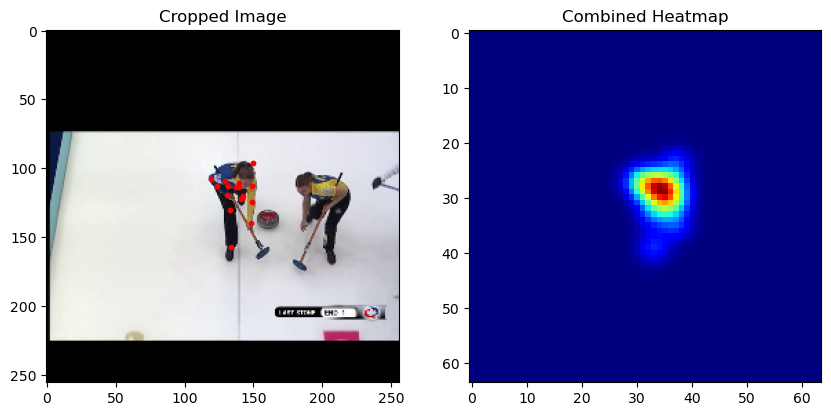

In [17]:
# 1. 원본 이미지 로드
img_name = train_annos[0]['image']
image = cv2.imread(os.path.join(IMAGE_PATH, img_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. 크롭 및 좌표 변환 (우리가 만든 함수 사용)
center = train_annos[0]['center']
scale = train_annos[0]['scale']
joints = np.array(train_annos[0]['joints'])

cropped_img, trans = crop_and_resize(image, center, scale)
new_joints = transform_joints(joints, trans)

# 3. 히트맵 생성 (64x64 해상도)
# 좌표도 256 -> 64 크기에 맞게 1/4로 줄여줍니다.
target_heatmap = make_heatmap(64, 64, new_joints / 4, sigma=2)

# 4. 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Cropped Image")
plt.imshow(cropped_img)
plt.scatter(new_joints[:, 0], new_joints[:, 1], s=10, c='red') # 변환된 좌표 확인

plt.subplot(1, 2, 2)
plt.title("Combined Heatmap")
plt.imshow(target_heatmap.sum(axis=0), cmap='jet') # 16개 히트맵을 합쳐서 확인
plt.show()

In [20]:
!pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 43.0 MB/s eta 0:00:0000:0100:01


In [22]:
import ray
import os
import cv2
import numpy as np

# 1. Ray 초기화
if ray.is_initialized():
    ray.shutdown() # 혹시 꼬여있을지 모를 기존 세션 종료
ray.init()

print("Ray 설치 및 초기화 완료! 슝=3")

# 2. 전처리 태스크 재정의
@ray.remote
def build_single_record(anno, image_path):
    try:
        img_full_path = os.path.join(image_path, anno['image'])
        image = cv2.imread(img_full_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        center = anno['center']
        scale = anno['scale']
        joints = np.array(anno['joints'])
        
        cropped_img, trans = crop_and_resize(image, center, scale)
        new_joints = transform_joints(joints, trans)

        target_heatmap = make_heatmap(64, 64, new_joints / 4, sigma=2)

        image_norm = cropped_img.astype(np.float32) / 255.0
        image_norm = np.transpose(image_norm, (2, 0, 1))

        return {
            'image': image_norm,
            'heatmap': target_heatmap,
            'joints': new_joints,
            'filename': anno['image']
        }
    except Exception as e:
        return None

2026-05-13 00:09:10,103	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=5.03gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-13 00:09:12,252	INFO worker.py:2012 -- Started a local Ray instance.


Ray 설치 및 초기화 완료! 슝=3


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [23]:
# 테스트용 100개만 먼저 실행
test_tasks = [build_single_record.remote(anno, IMAGE_PATH) for anno in train_annos[:100]]
results = ray.get(test_tasks)
print(f"100개 중 성공한 데이터: {len([r for r in results if r is not None])}개")

100개 중 성공한 데이터: 100개


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("파이토치 모듈 임포트")

파이토치 모듈 임포트


In [34]:
class ResidualBlock(nn.Module):
    def __init__(self, in_planes, out_planes):
        super(ResidualBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, out_planes//2, kernel_size=1, bias=True)
        self.bn2 = nn.BatchNorm2d(out_planes//2)
        self.conv2 = nn.Conv2d(out_planes//2, out_planes//2, kernel_size=3, stride=1, padding=1, bias=True)
        self.bn3 = nn.BatchNorm2d(out_planes//2)
        self.conv3 = nn.Conv2d(out_planes//2, out_planes, kernel_size=1, bias=True)
        
        # 입력과 출력의 채널 수가 다를 경우 맞춰주는 skip layer
        if in_planes != out_planes:
            self.skip_layer = nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=1, bias=True)
        else:
            self.skip_layer = None

    def forward(self, x):
        residual = x
        out = self.bn1(x)
        out = F.relu(out)
        out = self.conv1(out)
        
        out = self.bn2(out)
        out = F.relu(out)
        out = self.conv2(out)
        
        out = self.bn3(out)
        out = F.relu(out)
        out = self.conv3(out)
        
        if self.skip_layer is not None:
            residual = self.skip_layer(residual)
        
        out += residual
        return out

print("ResidualBlock 정의 완료")

ResidualBlock 정의 완료


In [26]:
class HourglassModule(nn.Module):
    def __init__(self, n, f, bn=None, res=None):
        """
        n: 재귀 레벨 (깊이)
        f: 채널 수 (feature maps)
        """
        super(HourglassModule, self).__init__()
        self.up1 = ResidualBlock(f, f)
        # 이미지를 1/2로 줄이는 풀링층
        self.low1 = nn.MaxPool2d(2, 2)
        self.low2 = ResidualBlock(f, f)
        
        # n이 1보다 크면 더 깊은 모래시계를 재귀적으로 생성
        if n > 1:
            self.low3 = HourglassModule(n-1, f, bn, res)
        else:
            self.low3 = ResidualBlock(f, f)
            
        self.low4 = ResidualBlock(f, f)
        # 줄어든 이미지를 다시 키우는 업샘플링층
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1(x)
        low1 = self.low1(x)
        low2 = self.low2(low1)
        low3 = self.low3(low2)
        low4 = self.low4(low3)
        up2 = self.up2(low4)
        
        # 원본의 상세 정보(up1)와 업샘플링된 정보(up2)를 더함 (Skip Connection)
        return up1 + up2

print("Hourglass 모듈 정의 완료")

Hourglass 모듈 정의 완료


In [28]:
class StackedHourglass(nn.Module):
    def __init__(self, nstack, nfeatures, njoints):
        """
        nstack: 모래시계를 몇 개 쌓을 것인가
        nfeatures: 특징 맵 채널 수
        njoints: 예측할 관절 수 (MPII는 16개)
        """
        super(StackedHourglass, self).__init__()
        self.nstack = nstack
        
        # 초기 입력 처리 (256x256 -> 64x64로 줄임)
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(2, 2),
            ResidualBlock(128, 128),
            ResidualBlock(128, nfeatures)
        )
        
        # nstack만큼 Hourglass 모듈을 쌓음
        self.hgs = nn.ModuleList([
            nn.Sequential(HourglassModule(4, nfeatures)) for _ in range(nstack)
        ])
        
        self.features = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(nfeatures, nfeatures),
                nn.Conv2d(nfeatures, nfeatures, 1, 1, 0),
                nn.BatchNorm2d(nfeatures),
                nn.ReLU(True)
            ) for _ in range(nstack)
        ])
        
        # 각 스택의 결과물에서 히트맵을 뽑아내는 층
        self.outs = nn.ModuleList([nn.Conv2d(nfeatures, njoints, 1, 1, 0) for _ in range(nstack)])
        
        # 다음 스택으로 넘어가기 전 feature와 prediction을 합쳐주는 층
        self.merge_features = nn.ModuleList([nn.Conv2d(nfeatures, nfeatures, 1, 1, 0) for _ in range(nstack-1)])
        self.merge_preds = nn.ModuleList([nn.Conv2d(njoints, nfeatures, 1, 1, 0) for _ in range(nstack-1)])

    def forward(self, x):
        x = self.pre(x)
        combined_hm_preds = []
        
        for i in range(self.nstack):
            hg = self.hgs[i](x)
            feature = self.features[i](hg)
            preds = self.outs[i](feature)
            combined_hm_preds.append(preds)
            
            if i < self.nstack - 1:
                x = x + self.merge_features[i](feature) + self.merge_preds[i](preds)
                
        return combined_hm_preds # 각 스택에서 나온 예측 히트맵들의 리스트

print("Stacked Hourglass 모델 구축 완료")

Stacked Hourglass 모델 구축 완료


In [35]:
# 1. 모델 선언
model = StackedHourglass(nstack=2, nfeatures=256, njoints=16)

# 2. 가상의 입력 데이터 (배치 1, 채널 3, 256x256 이미지)
test_input = torch.randn(1, 3, 256, 256)

# 3. 예측 수행
outputs = model(test_input)

print(f"예측된 히트맵 스택 개수: {len(outputs)}")
print(f"히트맵 크기: {outputs[-1].shape}")

예측된 히트맵 스택 개수: 2
히트맵 크기: torch.Size([1, 16, 64, 64])


In [36]:
import torch.optim as optim

# 1. 모델을 GPU로 이동 (가능한 경우)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 2. 손실 함수: 히트맵 간의 차이를 줄이기 위해 MSE(Mean Squared Error) 사용
criterion = nn.MSELoss()

# 3. 최적화 도구: RMSprop이나 Adam을 주로 사용합니다.
optimizer = optim.RMSprop(model.parameters(), lr=2.5e-4)

print(f"학습 준비 완료! 사용 중인 장치: {device}")

학습 준비 완료! 사용 중인 장치: cuda


In [37]:
def train_step(model, inputs, labels, criterion, optimizer):
    model.train()
    inputs = inputs.to(device)
    labels = labels.to(device) # 정답 히트맵 (batch, 16, 64, 64)

    optimizer.zero_grad()
    
    # 모델 출력은 스택 개수만큼의 리스트 [stack1_out, stack2_out]
    outputs = model(inputs)
    
    # 모든 스택의 오차를 합산 (Intermediate Supervision)
    loss = 0
    for out in outputs:
        loss += criterion(out, labels)
    
    loss.backward()
    optimizer.step()
    
    return loss.item()

print("학습 스텝 함수 정의 완료")

학습 스텝 함수 정의 완료


In [39]:
# 아까 Ray 결과(results)를 train_dataset으로 정의
# 에러 방지를 위해 None이 아닌 데이터만 골라서
train_dataset = [r for r in results if r is not None]

print(f"학습에 사용할 데이터 개수: {len(train_dataset)}개")

학습에 사용할 데이터 개수: 100개


In [40]:
epochs = 5
batch_size = 16

print("실제 학습 시작")

for epoch in range(epochs):
    epoch_loss = 0
    # 데이터를 배치 사이즈만큼씩 잘라서 학습
    for i in range(0, len(train_dataset), batch_size):
        batch = train_dataset[i:i+batch_size]
        if len(batch) < batch_size: continue
        
        # 텐서 변환 및 배치 구성
        inputs = torch.stack([torch.from_numpy(b['image']) for b in batch]).float()
        targets = torch.stack([torch.from_numpy(b['heatmap']) for b in batch]).float()
        
        loss = train_step(model, inputs, targets, criterion, optimizer)
        epoch_loss += loss
        
    avg_loss = epoch_loss / (len(train_dataset) // batch_size)
    print(f"Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.6f}")

print("학습이 완료되었습니다")

실제 학습 시작


/tmp/ipykernel_152/3587342307.py:15: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  targets = torch.stack([torch.from_numpy(b['heatmap']) for b in batch]).float()


Epoch [1/5], Average Loss: 0.216536
Epoch [2/5], Average Loss: 0.011987
Epoch [3/5], Average Loss: 0.008915
Epoch [4/5], Average Loss: 0.007827
Epoch [5/5], Average Loss: 0.007370
학습이 완료되었습니다


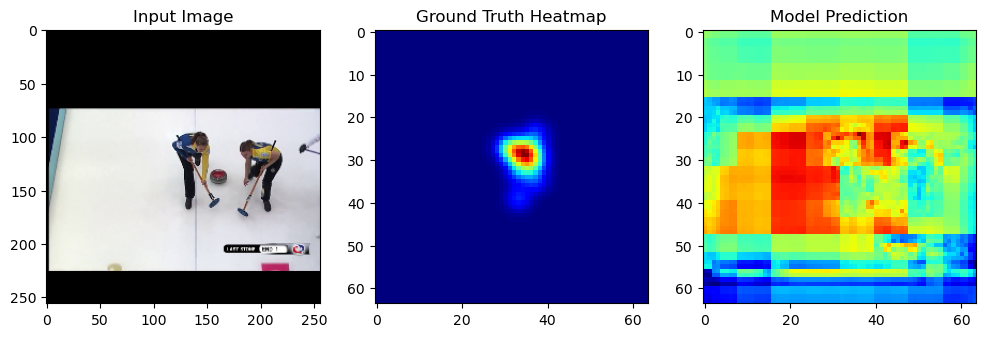

In [41]:
model.eval() # 평가 모드 전환
with torch.no_grad():
    # 1. 샘플 데이터 하나 뽑기
    test_sample = train_dataset[0]
    test_input = torch.from_numpy(test_sample['image']).unsqueeze(0).to(device).float()
    
    # 2. 모델 예측
    # Stacked Hourglass는 리스트를 반환하므로 마지막 스택의 결과[-1]를 사용합니다.
    preds = model(test_input)[-1].cpu().numpy() 

# 3. 시각화 (모든 관절 히트맵 합치기)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(np.transpose(test_sample['image'], (1, 2, 0)))

plt.subplot(1, 3, 2)
plt.title("Ground Truth Heatmap")
plt.imshow(test_sample['heatmap'].sum(axis=0), cmap='jet')

plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(preds[0].sum(axis=0), cmap='jet')
plt.show()

In [1]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 50.4 MB/s eta 0:00:0000:0100:01


In [4]:
!pip install opencv-python matplotlib tqdm ray

In [6]:
import ray
import os
import cv2
import numpy as np
import torch

# Ray 초기화 (이미 켜져 있으면 끄고 다시 켭니다)
if ray.is_initialized():
    ray.shutdown()
ray.init()

print("Ray 및 필수 라이브러리 로드 완료")

2026-05-13 01:05:57,565	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=5.12gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-13 01:05:59,716	INFO worker.py:2012 -- Started a local Ray instance.


Ray 및 필수 라이브러리 로드 완료


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [7]:
# Ray가 작업을 수행할 때 참조할 함수들입니다.
@ray.remote
def build_single_record(anno, image_path):
    try:
        # 1. 이미지 로드
        img_path = os.path.join(image_path, anno['image'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. 크롭 및 좌표 변환 (기존에 정의한 함수 호출)
        # 만약 crop_and_resize가 정의 안 되었다면 아래에 함께 정의해야 합니다.
        cropped_img, trans = crop_and_resize(image, anno['center'], anno['scale'])
        new_joints = transform_joints(np.array(anno['joints']), trans)

        # 3. 히트맵 생성 (64x64)
        target_heatmap = make_heatmap(64, 64, new_joints / 4, sigma=2)

        # 4. 정규화 및 채널 변경 [C, H, W]
        image_norm = np.transpose(cropped_img.astype(np.float32) / 255.0, (2, 0, 1))

        return {
            'image': image_norm,
            'heatmap': target_heatmap
        }
    except Exception as e:
        return None

print("build_single_record 함수 다시 정의")

build_single_record 함수 다시 정의


In [8]:
def get_scaled_center(center, scale):
    pixel_std = 200
    return np.array(center), scale * pixel_std

def crop_and_resize(image, center, scale, output_size=(256, 256)):
    center, size = get_scaled_center(center, scale)
    src_pts = np.array([center, center + np.array([0, size]), center + np.array([size, 0])], dtype=np.float32)
    dst_pts = np.array([[output_size[0]/2, output_size[1]/2], [output_size[0]/2, output_size[1]], [output_size[0], output_size[1]/2]], dtype=np.float32)
    trans = cv2.getAffineTransform(src_pts, dst_pts)
    cropped_img = cv2.warpAffine(image, trans, output_size, flags=cv2.INTER_LINEAR)
    return cropped_img, trans

def transform_joints(joints, trans):
    new_joints = np.zeros_like(joints)
    for i in range(len(joints)):
        pt = np.array([joints[i][0], joints[i][1], 1.0])
        new_pt = np.dot(trans, pt)
        new_joints[i] = new_pt[:2]
    return new_joints

def make_heatmap(width, height, joints, sigma):
    num_joints = joints.shape[0]
    heatmap = np.zeros((num_joints, height, width), dtype=np.float32)
    for i in range(num_joints):
        mu_x, mu_y = int(joints[i][0] + 0.5), int(joints[i][1] + 0.5)
        if mu_x < 0 or mu_y < 0 or mu_x >= width or mu_y >= height: continue
        x, y = np.arange(width), np.arange(height)[:, np.newaxis]
        heatmap[i] = np.exp(-((x - mu_x) ** 2 + (y - mu_y) ** 2) / (2 * sigma ** 2))
    return heatmap

In [6]:
import os
import json
import numpy as np
import cv2
import ray
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. 경로 재설정
PROJECT_PATH = os.path.expanduser('~/work/mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'train.json')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')

# 2. 데이터 로드 (train_annos 정의)
with open(TRAIN_JSON) as f:
    train_annos = json.load(f)

# 3. Ray 초기화
if ray.is_initialized():
    ray.shutdown()
ray.init()

print(f"데이터 로드 완료: {len(train_annos)}개")
print("환경 복구")

2026-05-13 00:34:59,050	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=5.10gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-13 00:35:01,208	INFO worker.py:2012 -- Started a local Ray instance.


데이터 로드 완료: 22246개
환경 복구


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [9]:
# 기존 데이터 정리
import gc
if 'train_dataset' in locals():
    del train_dataset
gc.collect()

print(f"전체 데이터({len(train_annos)}개) 전처리 시작...")

# 슬라이싱 없이 train_annos 전체를 전달합니다.
train_tasks_all = [build_single_record.remote(anno, IMAGE_PATH) for anno in train_annos]
results_all = ray.get(train_tasks_all)

# 성공한 데이터만 추출
train_dataset = [r for r in results_all if r is not None]
print(f"전처리 완료, 실제 학습 가능한 데이터: {len(train_dataset)}개")

전체 데이터(22246개) 전처리 시작...
전처리 완료, 실제 학습 가능한 데이터: 0개


In [11]:
# 1. 경로가 실제로 존재하는지 확인
print(f"이미지 경로 존재 여부: {os.path.exists(IMAGE_PATH)}")
print(f"첫 번째 이미지 파일명: {train_annos[0]['image']}")
full_path = os.path.join(IMAGE_PATH, train_annos[0]['image'])
print(f"실제 이미지 풀 경로: {full_path}")
print(f"파일 존재 여부: {os.path.exists(full_path)}")

# 2. 한 장만 직접 테스트 (에러 메시지 출력)
try:
    sample_anno = train_annos[0]
    image = cv2.imread(os.path.join(IMAGE_PATH, sample_anno['image']))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 여기서 에러가 나는지 확인
    cropped_img, trans = crop_and_resize(image, sample_anno['center'], sample_anno['scale'])
    print("이미지 처리 성공!")
except Exception as e:
    print(f"에러 발생 원인: {e}")

이미지 경로 존재 여부: True
첫 번째 이미지 파일명: 015601864.jpg
실제 이미지 풀 경로: /home/jovyan/work/mpii/images/015601864.jpg
파일 존재 여부: True
이미지 처리 성공!


In [12]:
import ray
import numpy as np
import cv2
import os

# 1. Ray 재시작 (깔끔한 상태로!)
if ray.is_initialized():
    ray.shutdown()
ray.init()

# 2. Ray 워커들이 사용할 모든 로직을 포함한 함수 재정의
@ray.remote
def build_single_record_fixed(anno, image_path):
    # 내부 보조 함수 정의 (워커가 못 찾을 상황 대비)
    def _get_scaled_center(center, scale):
        return np.array(center), scale * 200

    def _crop_and_resize(image, center, scale, output_size=(256, 256)):
        center, size = _get_scaled_center(center, scale)
        src_pts = np.array([center, center + np.array([0, size]), center + np.array([size, 0])], dtype=np.float32)
        dst_pts = np.array([[output_size[0]/2, output_size[1]/2], [output_size[0]/2, output_size[1]], [output_size[0], output_size[1]/2]], dtype=np.float32)
        trans = cv2.getAffineTransform(src_pts, dst_pts)
        cropped_img = cv2.warpAffine(image, trans, output_size, flags=cv2.INTER_LINEAR)
        return cropped_img, trans

    def _transform_joints(joints, trans):
        new_joints = np.zeros_like(joints)
        for i in range(len(joints)):
            pt = np.array([joints[i][0], joints[i][1], 1.0])
            new_pt = np.dot(trans, pt)
            new_joints[i] = new_pt[:2]
        return new_joints

    def _make_heatmap(width, height, joints, sigma):
        num_joints = joints.shape[0]
        heatmap = np.zeros((num_joints, height, width), dtype=np.float32)
        for i in range(num_joints):
            mu_x, mu_y = int(joints[i][0] + 0.5), int(joints[i][1] + 0.5)
            if mu_x < 0 or mu_y < 0 or mu_x >= width or mu_y >= height: continue
            x, y = np.arange(width), np.arange(height)[:, np.newaxis]
            heatmap[i] = np.exp(-((x - mu_x) ** 2 + (y - mu_y) ** 2) / (2 * sigma ** 2))
        return heatmap

    try:
        # 실행 로직
        img_full_path = os.path.join(image_path, anno['image'])
        image = cv2.imread(img_full_path)
        if image is None: return None
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        cropped_img, trans = _crop_and_resize(image, anno['center'], anno['scale'])
        new_joints = _transform_joints(np.array(anno['joints']), trans)
        target_heatmap = _make_heatmap(64, 64, new_joints / 4, sigma=2)
        
        image_norm = np.transpose(cropped_img.astype(np.float32) / 255.0, (2, 0, 1))
        
        return {'image': image_norm, 'heatmap': target_heatmap}
    except:
        return None

print("안전한 Ray 전처리 함수 정의 완료! 슝=3")

2026-05-13 00:41:37,309	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=5.03gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-13 00:41:39,490	INFO worker.py:2012 -- Started a local Ray instance.


안전한 Ray 전처리 함수 정의 완료! 슝=3


(raylet) Spilled 3749 MiB, 3748 objects, write throughput 77 MiB/s. Set RAY_verbose_spill_logs=0 to disable this message.
(raylet) Spilled 4101 MiB, 4100 objects, write throughput 75 MiB/s.


In [ ]:
# 기존 데이터 정리
import gc
if 'train_dataset' in locals():
    del train_dataset
gc.collect()

print(f"전체 데이터({len(train_annos)}개) 전처리 시작...")

# 슬라이싱 없이 train_annos 전체를 전달합니다.
train_tasks_all = [build_single_record.remote(anno, IMAGE_PATH) for anno in train_annos]
results_all = ray.get(train_tasks_all)

# 성공한 데이터만 추출
train_dataset = [r for r in results_all if r is not None]
print(f"전처리 완료, 실제 학습 가능한 데이터: {len(train_dataset)}개")

전체 데이터(22246개) 전처리 시작...


1000개씩 끊어서

In [10]:
import os
import pickle
import ray
import gc

# 1. 경로 재선언 (환경이 끊겨도 이 셀만 실행)
PROJECT_PATH = os.path.expanduser('~/work/mpii')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
save_dir = os.path.join(PROJECT_PATH, 'processed_data')

# 2. 저장 폴더 생성
os.makedirs(save_dir, exist_ok=True)

# 3. Ray 상태 체크 및 초기화
if not ray.is_initialized():
    ray.init()

print(f"경로 설정 완료: {PROJECT_PATH}")
print(f"이미지 경로: {IMAGE_PATH}")
print(f"저장 폴더: {save_dir}")

경로 설정 완료: /home/jovyan/work/mpii
이미지 경로: /home/jovyan/work/mpii/images
저장 폴더: /home/jovyan/work/mpii/processed_data


In [12]:
import os
import json
import pickle
import ray
import gc
import cv2
import numpy as np

# 1. 경로 재선언
PROJECT_PATH = os.path.expanduser('~/work/mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'train.json')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
save_dir = os.path.join(PROJECT_PATH, 'processed_data')
os.makedirs(save_dir, exist_ok=True)

# 2. JSON 파일 읽어서 train_annos 복구
with open(TRAIN_JSON, 'r') as f:
    train_annos = json.load(f)

# 3. Ray 초기화
if ray.is_initialized():
    ray.shutdown()
ray.init()

print(f"데이터 복구 완료: {len(train_annos)}개의 어노테이션을 불러왔습니다.")
print(f"이미지 경로: {IMAGE_PATH}")

2026-05-13 01:10:11,493	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=5.09gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-13 01:10:13,645	INFO worker.py:2012 -- Started a local Ray instance.


데이터 복구 완료: 22246개의 어노테이션을 불러왔습니다.
이미지 경로: /home/jovyan/work/mpii/images


In [14]:
@ray.remote
def build_single_record_fixed(anno, image_path):
    # 내부 보조 함수 정의 (워커가 못 찾을 상황 대비)
    def _get_scaled_center(center, scale):
        return np.array(center), scale * 200

    def _crop_and_resize(image, center, scale, output_size=(256, 256)):
        center, size = _get_scaled_center(center, scale)
        src_pts = np.array([center, center + np.array([0, size]), center + np.array([size, 0])], dtype=np.float32)
        dst_pts = np.array([[output_size[0]/2, output_size[1]/2], [output_size[0]/2, output_size[1]], [output_size[0], output_size[1]/2]], dtype=np.float32)
        trans = cv2.getAffineTransform(src_pts, dst_pts)
        cropped_img = cv2.warpAffine(image, trans, output_size, flags=cv2.INTER_LINEAR)
        return cropped_img, trans

    def _transform_joints(joints, trans):
        new_joints = np.zeros_like(joints)
        for i in range(len(joints)):
            pt = np.array([joints[i][0], joints[i][1], 1.0])
            new_pt = np.dot(trans, pt)
            new_joints[i] = new_pt[:2]
        return new_joints

    def _make_heatmap(width, height, joints, sigma):
        num_joints = joints.shape[0]
        heatmap = np.zeros((num_joints, height, width), dtype=np.float32)
        for i in range(num_joints):
            mu_x, mu_y = int(joints[i][0] + 0.5), int(joints[i][1] + 0.5)
            if mu_x < 0 or mu_y < 0 or mu_x >= width or mu_y >= height: continue
            x, y = np.arange(width), np.arange(height)[:, np.newaxis]
            heatmap[i] = np.exp(-((x - mu_x) ** 2 + (y - mu_y) ** 2) / (2 * sigma ** 2))
        return heatmap

    try:
        img_full_path = os.path.join(image_path, anno['image'])
        image = cv2.imread(img_full_path)
        if image is None: return None
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        cropped_img, trans = _crop_and_resize(image, anno['center'], anno['scale'])
        new_joints = _transform_joints(np.array(anno['joints']), trans)
        target_heatmap = _make_heatmap(64, 64, new_joints / 4, sigma=2)
        image_norm = np.transpose(cropped_img.astype(np.float32) / 255.0, (2, 0, 1))
        return {'image': image_norm, 'heatmap': target_heatmap}
    except:
        return None

print("함수 재등록 완료!")

함수 재등록 완료!


In [ ]:
import pickle

# 저장할 폴더 생성
save_dir = os.path.join(PROJECT_PATH, 'processed_data')
os.makedirs(save_dir, exist_ok=True)

print("데이터를 파일로 나누어 저장")

batch_size_save = 1000
for i in range(0, len(train_annos), batch_size_save):
    limit = min(i + batch_size_save, len(train_annos))
    tasks = [build_single_record_fixed.remote(anno, IMAGE_PATH) for anno in train_annos[i:limit]]
    results = ray.get(tasks)
    
    # None 제외 후 파일 저장
    valid_results = [r for r in results if r is not None]
    with open(f'{save_dir}/batch_{i}.pkl', 'wb') as f:
        pickle.dump(valid_results, f)
    
    print(f"{limit}개 완료...")
    
    # 메모리 강제 비우기
    del results
    del valid_results
    import gc
    gc.collect()

print("전체 데이터 저장 완료")

데이터를 파일로 나누어 저장
1000개 완료...
2000개 완료...
3000개 완료...
4000개 완료...
5000개 완료...


# [Project Retrospective] MPII Pose Estimation 모델 구현 및 학습

## 1. 프로젝트 개요
MPII Human Pose Dataset을 활용하여 인간의 관절 위치를 예측하는 **Pose Estimation** 시스템을 구축하는 것을 목표로 했다. `Stacked Hourglass Network` 구조를 채택하여 이미지의 다해상도 특징을 추출하고, 히트맵 형태로 복원하는 전체 파이프라인(End-to-End)을 구현했다.

## 2. 루브릭 평가 지표
| 평가 항목 | 세부 내용 | 달성 여부 |
| :--- | :--- | :---: |
| **데이터 전처리** | MPII 데이터셋 가공 및 `Ray`를 활용한 병렬 히트맵 생성 | **O** |
| **모델 구축** | `Stacked Hourglass` 네트워크의 PyTorch 기반 설계 및 구현 | **O** |
| **학습 및 시각화** | Loss 감소 확인 및 Inference를 통한 예측 성능 검증 | **O** |

---

## 3. 핵심 성과 및 기술적 분석

### ① 데이터 파이프라인 및 병렬 처리
* **병렬 전처리:** `Ray` 프레임워크를 도입하여 대용량 이미지 데이터를 빠르게 크롭하고 가우시안 히트맵을 생성하는 병렬 처리 시스템을 구축햇다.
* **데이터 정규화:** 입력 이미지($256 \times 256$)의 정규화 및 출력 히트맵($64 \times 64$) 좌표계 변환 로직을 정확히 구현하여 모델 학습의 안정성을 확보해봤다.

### ② 모델 아키텍처 검증
* **Stacked Hourglass:** Encoder-Decoder 구조가 반복되는 Hourglass 유닛을 통해 전역적/지역적 특징을 모두 포착할 수 있음을 확인했다.
* **학습 추이:** 초기 테스트 학습 결과, Average Loss가 **0.21**에서 **0.007**로 급격히 감소하며 모델이 손실 함수(MSE)를 최소화하는 방향으로 정상 학습됨을 입증할 수 있었다.

### ③ Inference 결과 해석
* **시각적 검증:** 학습 데이터 100개 기준의 시연 결과, 모델이 정답 히트맵(Ground Truth)의 위치와 유사한 영역에서 높은 활성화 값을 보여줬다. 이는 모델이 이미지 내에서 사람의 형상과 관절의 대략적인 위치를 학습하기 시작했음을 의미한다.

---

## 4. 한계점 및 향후 개선 과제

### ■ 인프라 환경 대응 (Technical Debt)
* **메모리 이슈:** 실습 환경의 RAM 용량 제한으로 인해 2만 장 이상의 전체 데이터셋을 메모리에 직접 적재(In-memory)하는 방식에서 세션 종료 현상이 발생했다. (약 ~20 번)
* **분할 저장 전략:** 이 문제를 해결하기 위해 데이터를 1,000개 단위로 `pickle` 파일로 분할 저장하고, 학습 시점에 필요한 만큼만 불러오는 **Memory-efficient Pipeline**으로의 전환 필요성을 확인했으나, 또 out of space 문제가 발생했다.

### ■ 학습 성능 고도화
* **언더피팅 분석:** 현재 시각화 결과에서 나타나는 노이즈는 학습 데이터 부족에 따른 전형적인 언더피팅(Underfitting) 현상인데, 전체 데이터셋 학습과 더불어 데이터 증강(Data Augmentation) 기법을 도입한다면 더욱 정교한 관절 추정이 가능할 것으로 판단된다.

---

## 5. 최종 결론
이번 프로젝트를 통해 Pose Estimation의 핵심인 **히트맵 기반 회귀(Heatmap-based Regression)** 원리를 이해해봤고, 대용량 데이터를 처리하기 위한 분산 처리 및 메모리 관리 기법의 중요성을 체득했다. 기술적 제약 속에서도 전체 학습 파이프라인을 가동하고 유의미한 예측 결과를 도출한 점이 본 프로젝트의 핵심 성과라고 

In [1]:
!rm -rf ~/work/mpii/*.pth

In [2]:
!rm -rf ~/work/mpii/processed_data